In [1]:
# 第3章｜比 RF 更好用的決策樹模型：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1 lightgbm xgboost
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


In [2]:
QUICK_RUN = False  # True：減少參數搜尋次數，只用來快速檢查程式能不能跑

# 比隨機森林更好用的決策樹模型：Gradient Boosting

**對應影片**：第 3 章 單元 8「比 RF 更好用的 Decision tree 模型們」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| `ml.fundamental_features()` 準備資料 | `finlab.ml.feature.combine` 與 `finlab.ml.label` |
| 用準確率比較模型 | 另外看 AUC，並用 `sim()` 回測比較 |
| `RandomizedSearchCV(cv=3)` 隨機切分驗證資料 | 用 `TimeSeriesSplit` 依時間順序切分，驗證資料永遠在訓練資料之後 |
| LightGBM 的 `silent=True` 參數 | 新版改用 `verbose=-1` |

Gradient Boosting 一棵一棵地種樹，每一棵新樹專門修正前面的樹猜錯的地方。
XGBoost 與 LightGBM 是兩個最常用的實作。

In [3]:
import numpy as np
import pandas as pd
import finlab.ml.feature as feature
import finlab.ml.label as label
from finlab.backtest import sim
from finlab.dataframe import FinlabDataFrame
from lightgbm import LGBMClassifier
from scipy.stats import randint, uniform
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBClassifier

REBALANCE = 'QE'
TRAIN_END = '2016-12-31'
RANDOM_STATE = 0
N_STOCKS = 30
MIN_FEATURE_COVERAGE = 0.5

## 1. 準備資料（和隨機森林單元相同）

In [4]:
feature_names = data.search('fundamental_features').str.split(':').str[1].tolist()

dataset = feature.combine(
    {name: data.get(f'fundamental_features:{name}') for name in feature_names}, resample=REBALANCE,
).replace([np.inf, -np.inf], np.nan)
dataset['return'] = label.return_percentage(dataset.index, resample=REBALANCE)
dataset['beat_median'] = label.excess_over_median(dataset.index, resample=REBALANCE) > 0
dataset = dataset.dropna(subset=['return'])
dataset = dataset[dataset[feature_names].notna().mean(axis=1) >= MIN_FEATURE_COVERAGE]

dates = dataset.index.get_level_values('datetime')
train, test = dataset[dates <= TRAIN_END], dataset[dates > TRAIN_END]
X_train, y_train = train[feature_names], train['beat_median']
X_test, y_test = test[feature_names], test['beat_median']
print(f'訓練資料 {len(train):,} 筆、測試資料 {len(test):,} 筆')

訓練資料 22,537 筆、測試資料 11,475 筆


## 2. 三種模型

三個模型都能直接處理缺值。

In [5]:
N_TREES = 300

models = {
    'Random forest': RandomForestClassifier(
        n_estimators=N_TREES, min_samples_leaf=50, n_jobs=-1, random_state=RANDOM_STATE),
    'XGBoost': XGBClassifier(
        n_estimators=N_TREES, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE),
    'LightGBM': LGBMClassifier(
        n_estimators=N_TREES, learning_rate=0.05, num_leaves=15, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, random_state=RANDOM_STATE, verbose=-1),
}

for model in models.values():
    model.fit(X_train, y_train)

## 3. 比較預測能力

- **準確率**：猜對的比例。
- **AUC**：模型把「會贏的股票」排在「會輸的股票」前面的機率。0.5 等於亂猜，越高越好。選股只需要排序對，所以 AUC 比準確率更貼近需求。

In [6]:
DECISION_THRESHOLD = 0.5

probabilities = {name: model.predict_proba(X_test)[:, 1] for name, model in models.items()}

pd.DataFrame({
    name: {'accuracy': accuracy_score(y_test, p > DECISION_THRESHOLD), 'AUC': roc_auc_score(y_test, p)}
    for name, p in probabilities.items()
}).T.style.format('{:.3f}')

,accuracy,AUC
Random forest,0.555,0.575
XGBoost,0.551,0.570
LightGBM,0.554,0.571


## 4. LightGBM 參數搜尋

`RandomizedSearchCV` 隨機試很多組參數，用交叉驗證挑出最好的。
股票資料有時間順序，所以用 `TimeSeriesSplit`：每次都用前面的資料訓練、後面的資料驗證。

In [7]:
N_SEARCH_ITERATIONS = 5 if QUICK_RUN else 40
N_SPLITS = 3

search = RandomizedSearchCV(
    LGBMClassifier(n_estimators=N_TREES, subsample_freq=1, random_state=RANDOM_STATE, verbose=-1),
    param_distributions={
        'num_leaves': randint(6, 50),
        'min_child_samples': randint(100, 500),
        'learning_rate': uniform(0.01, 0.1),
        'subsample': uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'reg_lambda': uniform(0, 10),
    },
    n_iter=N_SEARCH_ITERATIONS,
    scoring='roc_auc',
    cv=TimeSeriesSplit(n_splits=N_SPLITS),
    random_state=RANDOM_STATE,
    n_jobs=1,
)
search.fit(X_train, y_train)

print(f'驗證 AUC：{search.best_score_:.3f}')
search.best_params_

驗證 AUC：0.540


{'colsample_bytree': np.float64(0.7255796072604641),
 'learning_rate': np.float64(0.011998766540875875),
 'min_child_samples': 494,
 'num_leaves': 49,
 'reg_lambda': np.float64(1.201965612131689),
 'subsample': np.float64(0.6480700987610725)}

In [8]:
models['LightGBM (tuned)'] = search.best_estimator_
probabilities['LightGBM (tuned)'] = search.best_estimator_.predict_proba(X_test)[:, 1]
print(f"調整後 LightGBM 的測試 AUC：{roc_auc_score(y_test, probabilities['LightGBM (tuned)']):.3f}")

調整後 LightGBM 的測試 AUC：0.575


## 5. 回測比較

每季買各模型機率最高的 `N_STOCKS` 檔。

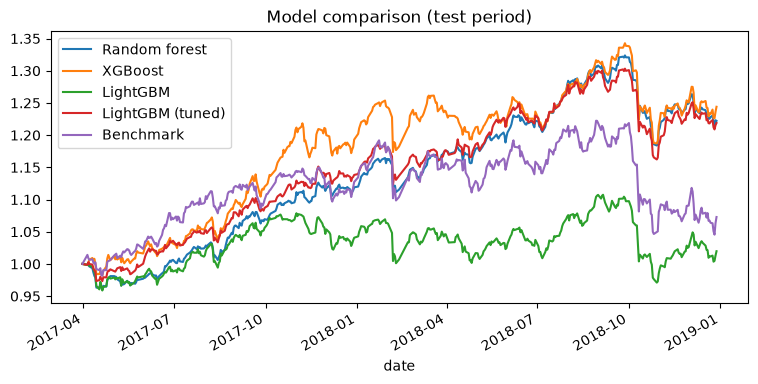

In [9]:
def backtest(probability: np.ndarray, name: str):
    score = FinlabDataFrame(pd.Series(probability, index=test.index).unstack('instrument'))
    return sim(score.is_largest(N_STOCKS), name=name)


reports = {name: backtest(p, name) for name, p in probabilities.items()}

curves = pd.DataFrame({name: report.creturn for name, report in reports.items()})
benchmark = reports['LightGBM'].benchmark.reindex(curves.index)
curves['Benchmark'] = benchmark / benchmark.dropna().iloc[0]
curves.plot(figsize=(9, 4), title='Model comparison (test period)');

In [10]:
pd.DataFrame({
    name: {key: report.get_stats()[key] for key in ['cagr', 'max_drawdown', 'daily_sharpe']}
    for name, report in reports.items()
}).T.style.format({'cagr': '{:.2%}', 'max_drawdown': '{:.2%}', 'daily_sharpe': '{:.2f}'})

,cagr,max_drawdown,daily_sharpe
Random forest,12.19%,-10.57%,1.15
XGBoost,13.34%,-11.59%,1.01
LightGBM,1.13%,-12.32%,-0.03
LightGBM (tuned),12.01%,-10.82%,1.08


測試期間只有幾年，模型之間的差距可能只是運氣。挑模型時，除了看回測結果，也要看驗證資料上的 AUC 是否穩定。